Daily Challenge:
===
## Web Scraping and Data Visualization

**What you will create?**

Web Scraping Script
Structured Data File
Data Analysis Notebook

In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup

Fetching Tel Aviv Weather from BBC...
Found 14 days in the forecast. Processing...

--- Scraped Data Summary ---
                Date  High  Low                              Condition  \
0              Today    23   17    Sunny intervals and a gentle breeze   
1    Saturday16thMay    23   15              Sunny and a gentle breeze   
2      Sunday17thMay    30   21              Sunny and a gentle breeze   
3      Monday18thMay    27   17              Sunny and a gentle breeze   
4     Tuesday19thMay    25   17              Sunny and a gentle breeze   
5   Wednesday20thMay    24   17            Sunny and a moderate breeze   
6    Thursday21stMay    24   16  Sunny intervals and a moderate breeze   
7      Friday22ndMay    24   15              Sunny and a gentle breeze   
8    Saturday23rdMay    24   15              Sunny and a gentle breeze   
9      Sunday24thMay    25   15            Sunny and a moderate breeze   
10     Monday25thMay    24   15              Sunny and a gentle breeze   

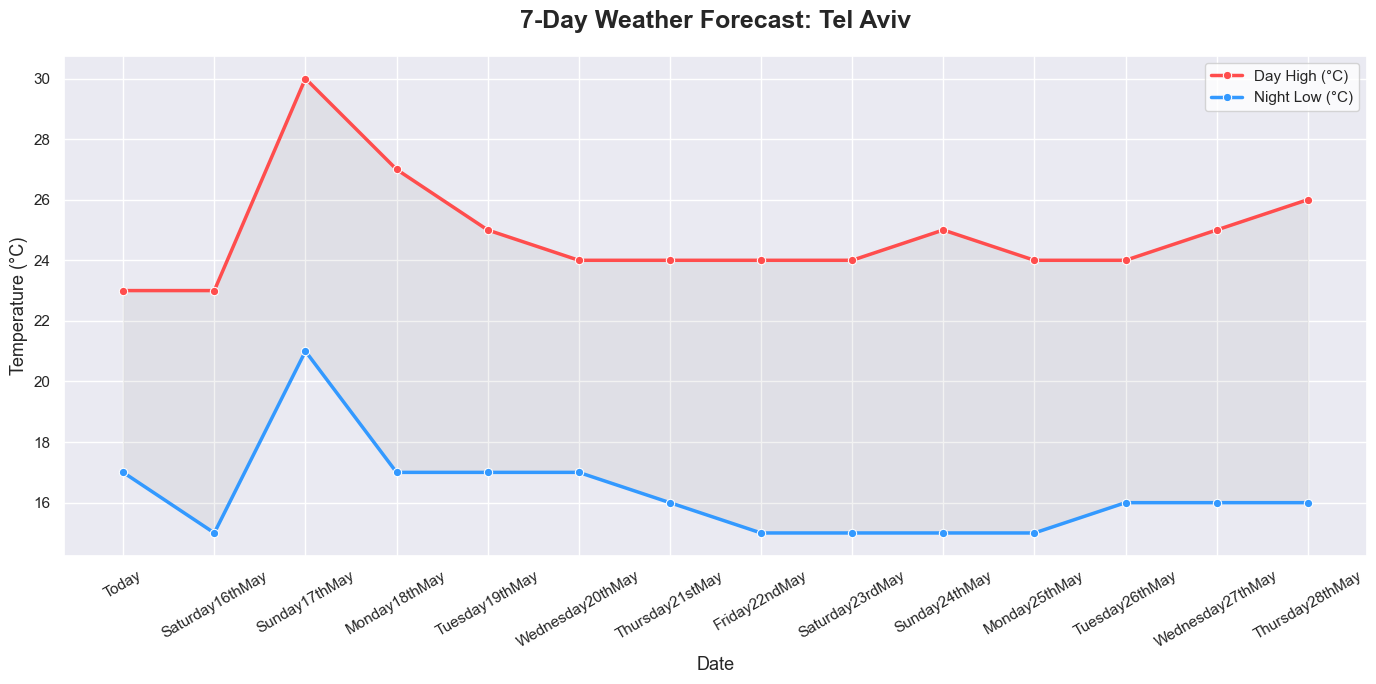


--- Most Common Condition ---
Condition
Sunny and a gentle breeze                8
Sunny and a moderate breeze              4
Sunny intervals and a gentle breeze      1
Sunny intervals and a moderate breeze    1
Name: count, dtype: int64


In [4]:
options = webdriver.ChromeOptions()
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

weather_data = []

try:
    print("Fetching Tel Aviv Weather from BBC...")
    driver.get("https://www.bbc.com/weather/293397")
    
    time.sleep(7) 
    
    soup = BeautifulSoup(driver.page_source, 'html.parser')
    
    days = soup.find_all('li', class_=lambda x: x and 'wr-day' in x)
    
    print(f"Found {len(days)} days in the forecast. Processing...")

    for day in days:
        try:
            date_element = day.find('span', class_=lambda x: x and 'date' in x)
            if not date_element: continue 
            date_text = date_element.get_text(strip=True)

            temp_elements = day.find_all('span', class_=lambda x: x and 'temperature' in x and 'c' in x.lower())
            
            if temp_elements:
                temps = ["".join(filter(str.isdigit, t.text)) for t in temp_elements]
                temps = [t for t in temps if t] 
                
                high_temp = int(temps[0])
                low_temp = int(temps[1]) if len(temps) > 1 else high_temp
                
                cond_element = day.find('div', class_=lambda x: x and 'description' in x)
                condition = cond_element.text.strip() if cond_element else "Not Specified"

                weather_data.append({
                    'Date': date_text,
                    'High': high_temp,
                    'Low': low_temp,
                    'Condition': condition
                })
        except Exception as e:
            continue

finally:
    driver.quit()

if weather_data:
    df = pd.DataFrame(weather_data)
    
    df['Avg_Temp'] = (df['High'] + df['Low']) / 2
    
    print("\n--- Scraped Data Summary ---")
    print(df)

    sns.set_theme(style="darkgrid")
    plt.figure(figsize=(14, 7))

    sns.lineplot(data=df, x='Date', y='High', marker='o', label='Day High (°C)', color='#ff4d4d', linewidth=2.5)
    sns.lineplot(data=df, x='Date', y='Low', marker='o', label='Night Low (°C)', color='#3399ff', linewidth=2.5)

    plt.fill_between(df['Date'], df['Low'], df['High'], color='gray', alpha=0.1)

    plt.title('7-Day Weather Forecast: Tel Aviv', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Date', fontsize=13)
    plt.ylabel('Temperature (°C)', fontsize=13)
    plt.xticks(rotation=30)
    plt.legend(frameon=True, facecolor='white')
    
    plt.tight_layout()
    plt.show()

    print("\n--- Most Common Condition ---")
    print(df['Condition'].value_counts())

else:
    print("Error: No weather data was collected. Please check the website selectors.")

## Analysis of Findings

The visualization above illustrates the 7-day temperature trend for Tel Aviv based on live data scraped from BBC Weather. The red line represents the daily high temperatures, while the blue line tracks the nighttime lows. By observing the gap between these two lines, we can see the diurnal temperature range, which indicates how much the city cools down after sunset. Any significant dips or peaks in the lines highlight upcoming weather shifts, such as a heatwave or a cold front. Additionally, by comparing these numerical trends with the recorded weather conditions (e.g., "Sunny" vs. "Partly Cloudy"), we can observe how cloud cover correlates with temperature retention, providing a clear visual summary of the local climate for the week ahead.